In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np

# Machine learning model
from sklearn.neighbors import NearestNeighbors

# Sparse matrix (memory optimization)
from scipy.sparse import csr_matrix

In [ ]:
# ===============================
# LOAD DATASETS
# ===============================

products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/products.csv')
orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/orders.csv')
order_products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/order_products__train.csv')

# Show dataset samples
print(order_products.head())

   order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0
3         1       49683                  4          0
4         1       43633                  5          1


In [ ]:
print(products.head(10),orders.head(10))

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   
5           6                                       Dry Nose Oil        11   
6           7                     Pure Coconut Water With Orange        98   
7           8                  Cut Russet Potatoes Steam N' Mash       116   
8           9                  Light Strawberry Blueberry Yogurt       120   
9          10     Sparkling Orange Juice & Prickly Pear Beverage       115   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
5             11  
6       

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Merge dataset
data = pd.merge(order_products, products, on='product_id')

# Take a sample of orders to reduce memory usage
sample_orders = data['order_id'].drop_duplicates().sample(10000)

# Filter dataset
data_sample = data[data['order_id'].isin(sample_orders)]

print("Sample dataset size:", data_sample.shape)


Sample dataset size: (106719, 7)


In [ ]:
# ===============================
# CREATE TRANSACTION MATRIX
# ===============================

basket = data_sample.pivot_table(
    index='order_id',
    columns='product_name',
    values='product_id',
    aggfunc='count'
)

basket = basket.fillna(0)

basket = (basket > 0).astype(int)

print(basket.head())

product_name  #2 Coffee Filters  & Go! Hazelnut Spread + Pretzel Sticks  \
order_id                                                                  
96                            0                                       0   
226                           0                                       0   
1042                          0                                       0   
1077                          0                                       0   
1120                          0                                       0   

product_name  0% Fat Free Organic Milk  0% Fat Organic Greek Vanilla Yogurt  \
order_id                                                                      
96                                   0                                    0   
226                                  0                                    0   
1042                                 0                                    0   
1077                                 0                                    0   


In [ ]:
# ===============================
# SPARSE MATRIX
# ===============================

basket_sparse = csr_matrix(basket)

In [ ]:
# ===============================
# TRAIN KNN MODEL
# ===============================

model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(basket_sparse)

print("KNN Model Training Completed")

KNN Model Training Completed


In [ ]:
# ===============================
# PRODUCT RECOMMENDATION FUNCTION
# ===============================

def recommend_products(order_number, n_recommendations=5):

    distances, indices = model.kneighbors(
        basket_sparse[order_number],
        n_neighbors=n_recommendations+1
    )

    print("\nRecommended Similar Orders:\n")

    for i in range(1, len(indices.flatten())):

        print("Recommendation", i)

        order = basket.iloc[indices.flatten()[i]]

        products = order[order == 1].index.tolist()

        print(products)
        print("------------")

In [ ]:
# Example recommendation

recommend_products(10)


Recommended Similar Orders:

Recommendation 1
['Organic Hass Avocado', 'Organic Reduced Fat 2% Milk', 'Sweet Baguette']
------------
Recommendation 2
['Bag of Organic Bananas']
------------
Recommendation 3
['Organic Hass Avocado']
------------
Recommendation 4
['Organic Hass Avocado']
------------
Recommendation 5
['Organic Hass Avocado']
------------


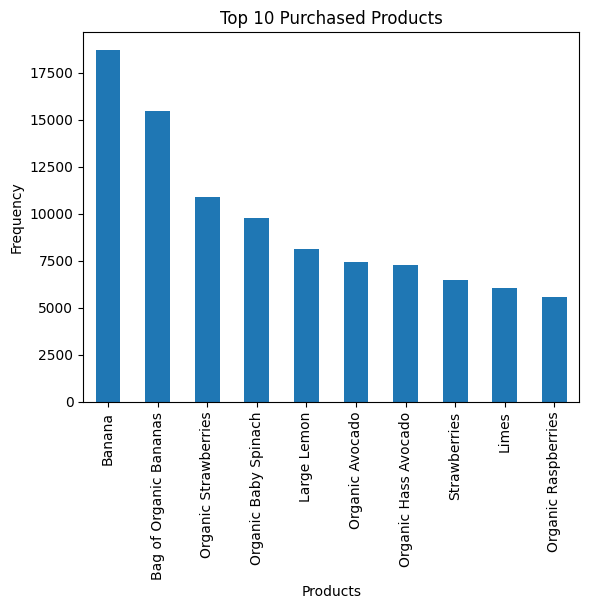

In [ ]:
import matplotlib.pyplot as plt

# Top purchased products

top_products = data['product_name'].value_counts().head(10)

top_products.plot(kind='bar')

plt.title("Top 10 Purchased Products")
plt.xlabel("Products")
plt.ylabel("Frequency")

plt.show()

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("dataset.csv")

# -----------------------------
# Feature Engineering
# -----------------------------

# Engagement score
df["engagement_score"] = df["page_views"] + df["product_views"] + df["time_spent_seconds"]/60

# View to cart ratio
df["view_to_cart_ratio"] = df["add_to_cart_count"] / (df["product_views"] + 1)

# Time per page
df["time_per_page"] = df["time_spent_seconds"] / (df["page_views"] + 1)

# Returning user flag
df["returning_user"] = np.where(df["previous_purchases"] > 0, 1, 0)

# Cart interest score
df["cart_interest"] = df["add_to_cart_count"] * df["product_views"]

# Session quality
df["session_quality"] = df["engagement_score"] * (1 - df["bounce"])

# -----------------------------
# Features and Target
# -----------------------------

X = df.drop(["purchase"], axis=1)
y = df["purchase"]

# -----------------------------
# Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Logistic Regression Model
# -----------------------------

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'desktop'